# Latent SOH Filtering Method Comparison (FilterPy)

This notebook sweeps FilterPy settings (measurement noise profile + process noise) to pick a canonical smoother, then reruns the latent SOH build using the chosen settings.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "ml_workspace").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "ml_workspace").exists():
            REPO_ROOT = parent
            break

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml_workspace.latent_soh.build_latent_soh import build_latent_soh_labels
from ml_workspace.latent_soh.condition_noise import RT_PROFILES

PLANE_ID = "166"
TIMESERIES_PATH = REPO_ROOT / "data" / "event_timeseries.parquet"
SPEC_PATH = REPO_ROOT / "ml_workspace" / "battery_specs.yaml"
BASE_OUT_DIR = REPO_ROOT / "ml_workspace" / "latent_soh" / "output" / "method_search"

BASE_OUT_DIR.mkdir(parents=True, exist_ok=True)

## Sweep setup

We select each candidate by average log-likelihood under the measurement model
(`observed_soh_pct ~ N(latent_soh_smooth_pct, measurement_sigma_pct)`).
The other metrics are kept for diagnostics and sanity checks:

- `avg_smoothed_total_variation`
- `avg_smoothed_max_upward_jump`
- `spike_removal_fraction`
- `residual_iqr`
- `avg_loglik` (higher is better)
- `total_loglik` (higher is better)

## Approach and Selection Rationale

### Problem framing
Observed SOH from the BMS is noisy and sometimes unstable. We model a latent SOH state that evolves
smoothly over time and is observed through a noisy measurement process. The goal is to produce a
stable, physically plausible SOH trajectory with an uncertainty estimate that downstream models can trust.

### State-space model (1D)
We use a linear 1D state-space model for SOH with time-varying measurement noise.
- State: latent_soh_t
- Process model: latent_soh_{t+1} = latent_soh_t + w_t, with w_t ~ N(0, Q_t)
- Measurement model: observed_soh_t = latent_soh_t + v_t, with v_t ~ N(0, R_t)

Where Q_t is controlled by q_day_sigma_pct (process noise per day) and R_t is determined by
rt_profile and condition scores (current, dI/dt, dT/dt, SOC edge behavior, estimator instability,
gap flags, and reset flags). This makes the filter more conservative when the observations are
unreliable and more responsive when telemetry looks trustworthy.

### Candidate sweep
We sweep a small grid of:
- rt_profile (measurement noise aggressiveness)
- q_day_sigma_pct (process noise scale)

Each candidate runs a FilterPy Kalman filter + RTS smoother and emits:
- latent_soh_smooth_pct (canonical series)
- latent_soh_smooth_std_pct (uncertainty)

### Selection criterion (likelihood-based)
We avoid hand-tuned weighted scores. For each candidate we compute the measurement-model
log-likelihood under:
observed_soh_pct ~ N(latent_soh_smooth_pct, measurement_sigma_pct^2).

We rank candidates by avg_loglik (higher is better). This is the statistically consistent way to
select Kalman settings because it directly measures how well each model explains the observations
under its own noise assumptions.

### Diagnostics retained (not used for selection)
We also compute diagnostic metrics for sanity checks:
- avg_smoothed_total_variation
- avg_smoothed_max_upward_jump
- spike_removal_fraction
- residual_iqr

These help detect oversmoothing or under-smoothing, but the final ranking is by likelihood.

### Final fit and outputs
The best candidate (highest avg_loglik) is re-run and written to the canonical output directory.
Downstream forecasting and scheduling should use:
- latent_soh_filter_pct (alias: latent_soh_causal_pct) as the target series
- latent_soh_filter_std_pct (alias: latent_soh_causal_std_pct) as the uncertainty band

RTS-smoothed outputs (latent_soh_smooth_pct) use future observations and are not causal. They are
recommended only for retrospective analysis or reporting.

### Why this final fit
- Maximum-likelihood selection avoids arbitrary weights and aligns with Kalman theory.
- Time-varying measurement noise prevents spikes or unstable telemetry from dominating the state.
- RTS smoothing yields a stable trajectory while preserving interpretability and uncertainty estimates.

In [2]:
def _series_total_variation(values: pd.Series) -> float:
    diffs = values.diff().dropna()
    if diffs.empty:
        return 0.0
    return float(diffs.abs().sum())


def _series_max_upward(values: pd.Series) -> float:
    diffs = values.diff().dropna()
    if diffs.empty:
        return 0.0
    return float(diffs.max())


def compute_candidate_metrics(latent_df: pd.DataFrame, spike_threshold_pct: float) -> dict[str, float]:
    df = latent_df.sort_values(["plane_id", "battery_id", "event_datetime", "flight_id"]).copy()
    df["delta_observed"] = df.groupby(["plane_id", "battery_id"], observed=True)["observed_soh_pct"].diff()
    df["delta_latent"] = df.groupby(["plane_id", "battery_id"], observed=True)["latent_soh_smooth_pct"].diff()

    spike_mask = df["delta_observed"] >= float(spike_threshold_pct)
    if spike_mask.any():
        spike_removed = (df["delta_latent"] < float(spike_threshold_pct)) & spike_mask
        spike_removal_fraction = float(spike_removed.sum() / spike_mask.sum())
    else:
        spike_removal_fraction = 1.0

    residual = df["observed_soh_pct"] - df["latent_soh_smooth_pct"]
    residual_iqr = float(residual.quantile(0.75) - residual.quantile(0.25))

    sigma = df["measurement_sigma_pct"].astype(float)
    sigma = sigma.where(sigma > 0)
    loglik = -0.5 * np.log(2.0 * np.pi * (sigma ** 2)) - 0.5 * (residual ** 2) / (sigma ** 2)
    avg_loglik = float(loglik.mean())
    total_loglik = float(loglik.sum())

    by_batt = df.groupby(["plane_id", "battery_id"], observed=True)
    avg_smoothed_total_variation = float(by_batt["latent_soh_smooth_pct"].apply(_series_total_variation).mean())
    avg_smoothed_max_upward_jump = float(by_batt["latent_soh_smooth_pct"].apply(_series_max_upward).mean())

    return {
        "avg_smoothed_total_variation": avg_smoothed_total_variation,
        "avg_smoothed_max_upward_jump": avg_smoothed_max_upward_jump,
        "spike_removal_fraction": spike_removal_fraction,
        "residual_iqr": residual_iqr,
        "avg_loglik": avg_loglik,
        "total_loglik": total_loglik,
    }

In [3]:
REUSE_EXISTING = False
SPIKE_THRESHOLD_PCT = 2.0

rt_profiles = sorted(RT_PROFILES)
q_day_grid = [0.02, 0.05, 0.08, 0.10]


def run_candidate(rt_profile: str, q_day_sigma_pct: float) -> dict[str, object]:
    out_dir = BASE_OUT_DIR / f"plane_{PLANE_ID}" / f"rt_{rt_profile}_q_{q_day_sigma_pct:.3f}"
    event_path = out_dir / "latent_soh_event_table.csv"

    if not (REUSE_EXISTING and event_path.exists()):
        build_latent_soh_labels(
            plane_id=PLANE_ID,
            timeseries_path=TIMESERIES_PATH,
            spec_path=SPEC_PATH,
            output_dir=out_dir,
            q_day_sigma_pct=q_day_sigma_pct,
            spike_threshold_pct=SPIKE_THRESHOLD_PCT,
            rt_profile=rt_profile,
        )

    latent_df = pd.read_csv(event_path)
    metrics = compute_candidate_metrics(latent_df, spike_threshold_pct=SPIKE_THRESHOLD_PCT)
    return {
        "rt_profile": rt_profile,
        "q_day_sigma_pct": q_day_sigma_pct,
        **metrics,
    }

In [4]:
results = []
for rt_profile in rt_profiles:
    for q_day_sigma_pct in q_day_grid:
        results.append(run_candidate(rt_profile, q_day_sigma_pct))

results_df = pd.DataFrame(results).sort_values("avg_loglik", ascending=False).reset_index(drop=True)
results_df

,rt_profile,q_day_sigma_pct,avg_smoothed_total_variation,avg_smoothed_max_upward_jump,spike_removal_fraction,residual_iqr,avg_loglik,total_loglik
0,current,0.10,46.185265,0.713008,1.000000,3.654951,-3.350561,-3705.720262
1,current,0.08,40.639955,0.391829,1.000000,4.346911,-3.497701,-3868.457411
2,current,0.05,31.090191,0.003324,1.000000,5.773080,-3.878552,-4289.678408
3,balanced,0.10,74.923817,3.121107,1.000000,3.024926,-5.086480,-5625.646414
4,current,0.02,14.911194,-0.000001,1.000000,11.275728,-5.540444,-6127.731119
5,balanced,0.08,65.653591,2.295952,1.000000,3.174147,-5.782745,-6395.715520
6,instability_focused,0.10,86.161238,4.193376,0.986111,2.911315,-6.062012,-6704.585651
7,light,0.10,94.004616,4.941050,0.972222,2.684054,-6.900596,-7632.059115
8,instability_focused,0.08,75.808296,3.209209,1.000000,3.017287,-7.084573,-7835.537658
9,balanced,0.05,50.420748,1.023682,1.000000,3.479264,-7.347571,-8126.413277


## Choose the best candidate and rebuild canonical outputs

In [5]:
best = results_df.iloc[0]
best

rt_profile                          current
q_day_sigma_pct                         0.1
avg_smoothed_total_variation      46.185265
avg_smoothed_max_upward_jump       0.713008
spike_removal_fraction                  1.0
residual_iqr                       3.654951
avg_loglik                        -3.350561
total_loglik                   -3705.720262
Name: 0, dtype: object

In [6]:
canonical_out = REPO_ROOT / "ml_workspace" / "latent_soh" / "output" / f"plane_{PLANE_ID}"
build_latent_soh_labels(
    plane_id=PLANE_ID,
    timeseries_path=TIMESERIES_PATH,
    spec_path=SPEC_PATH,
    output_dir=canonical_out,
    q_day_sigma_pct=float(best["q_day_sigma_pct"]),
    spike_threshold_pct=SPIKE_THRESHOLD_PCT,
    rt_profile=str(best["rt_profile"]),
)

{'plane_id': '166',
 'rt_profile': 'current',
 'output_dir': '/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/latent_soh/output/plane_166',
 'event_observation_rows': 1106,
 'latent_rows': 1106,
 'n_events_dropped_missing_observed_soh': 0,
 'smoother_summary': {'plane_id': '166',
  'rt_profile': 'current',
  'battery_ids_processed': [1, 2],
  'n_events_total': 1106,
  'n_events_per_battery': {'1': 553, '2': 553},
  'n_events_dropped_missing_observed_soh': 0,
  'sigma_base_pct_per_battery': {'1': 0.75, '2': 0.75},
  'q_day_sigma_pct': 0.1,
  'raw_total_variation_per_battery': {'1': 484.0, '2': 469.0},
  'smoothed_total_variation_per_battery': {'1': 46.890453654190104,
   '2': 45.48007571788718},
  'raw_max_upward_jump_pct_per_battery': {'1': 29.0, '2': 25.0},
  'smoothed_max_upward_jump_pct_per_battery': {'1': 0.7007609453654169,
   '2': 0.7252555863062184},
  'fraction_events_with_condition_multiplier_gt_3': {'1': 0.9493670886075949,
   '2': 0.9475587703435805},
  

## Quick visual sanity check

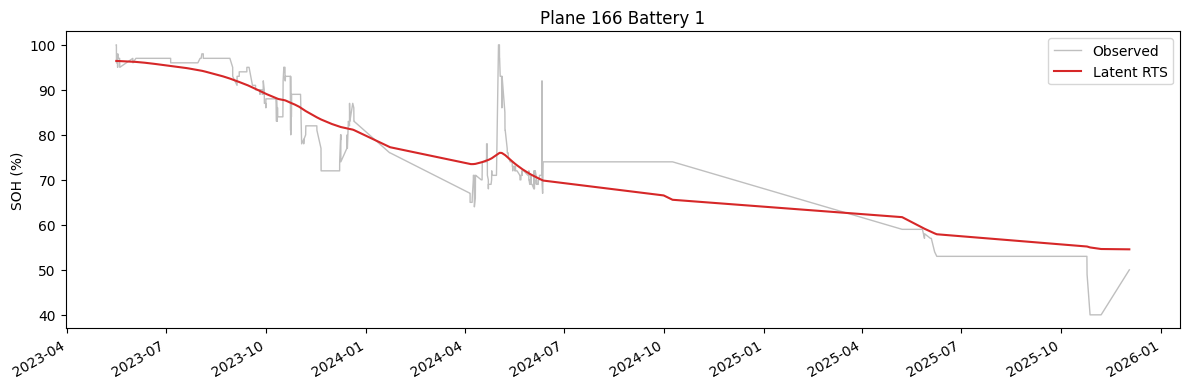

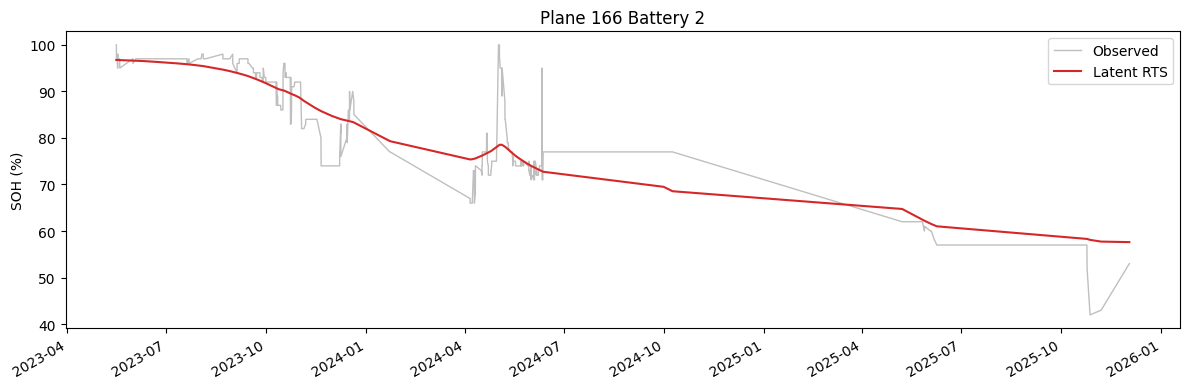

In [7]:
import matplotlib.pyplot as plt

latent_df = pd.read_csv(canonical_out / "latent_soh_event_table.csv")
latent_df["event_datetime"] = pd.to_datetime(latent_df["event_datetime"], errors="coerce")

for battery_id, group in latent_df.groupby("battery_id", sort=True, observed=True):
    g = group.sort_values(["event_datetime", "flight_id"])
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(g["event_datetime"], g["observed_soh_pct"], color="0.75", linewidth=1.0, label="Observed")
    ax.plot(g["event_datetime"], g["latent_soh_smooth_pct"], color="#d62728", linewidth=1.5, label="Latent RTS")
    ax.set_title(f"Plane {PLANE_ID} Battery {int(battery_id)}")
    ax.set_ylabel("SOH (%)")
    ax.legend(loc="best")
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()